In [54]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
import re
# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

#모든 컬럼 다 보이게
pd.set_option("display.max_columns", None)
#모든 행도 다 보이게
pd.set_option("display.max_rows", None)


#판다스가 화면에 보여줄 때 잘리지 않게 출력 옵션을 바꾸기
#pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

라이브러리 로드 완료!
한글 폰트 설정 완료!


## 1. metadata 불러오기

In [55]:
metadata = pd.read_csv("metadata.csv")
metadata.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [56]:
metadata.shape

(7565, 10)

## 2. 전처리
- 컬럼명 공백 제거
- 문자형 공백 제거
- `Capacity`, `Re`, `Rct`를 숫자형으로 변환
- `start_time`을 시간형으로 바꾸기

In [57]:
metadata.columns = metadata.columns.str.strip()

metadata["type"] = metadata["type"].astype(str).str.strip().str.lower()
metadata["battery_id"] = metadata["battery_id"].astype(str).str.strip()
metadata["filename"] = metadata["filename"].astype(str).str.strip()

for col in ["Capacity", "Re", "Rct"]:
    metadata[col] = pd.to_numeric(metadata[col], errors="coerce")

metadata.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.056058,0.200970
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.053192,0.164734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,NaN,NaN


In [58]:
parsed_times = []

for value in metadata["start_time"].astype(str):
    numbers = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", value)

    if len(numbers) >= 6:
        year = int(float(numbers[0]))
        month = int(float(numbers[1]))
        day = int(float(numbers[2]))
        hour = int(float(numbers[3]))
        minute = int(float(numbers[4]))
        second = float(numbers[5])

        second_int = int(second)
        microsecond = int(round((second - second_int) * 1_000_000))

        if microsecond >= 1_000_000:
            second_int = second_int + 1
            microsecond = microsecond - 1_000_000

        parsed_times.append(
            pd.Timestamp(year, month, day, hour, minute, second_int, microsecond)
        )
    else:
        parsed_times.append(pd.NaT)

metadata["start_time"] = pd.to_datetime(parsed_times, errors="coerce")

metadata[["battery_id", "type", "start_time", "filename"]].head()

,battery_id,type,start_time,filename
0,B0047,discharge,2010-07-21 15:00:35.093,00001.csv
1,B0047,impedance,2010-07-21 16:53:45.968,00002.csv
2,B0047,charge,2010-07-21 17:25:40.671,00003.csv
3,B0047,impedance,2010-07-21 20:31:05.000,00004.csv
4,B0047,discharge,2010-07-21 21:02:56.984,00005.csv


## 3. operation master 만들기

시간을 기준으로 정렬한 기본 표

In [59]:
operation_master = metadata.sort_values(
    ["battery_id", "start_time", "filename"]
).reset_index(drop=True)

operation_master.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,charge,2008-04-02 13:08:17.921,24,B0005,0,5121,05121.csv,NaN,NaN,NaN
1,discharge,2008-04-02 15:25:41.593,24,B0005,1,5122,05122.csv,1.856487,NaN,NaN
2,charge,2008-04-02 16:37:51.984,24,B0005,2,5123,05123.csv,NaN,NaN,NaN
3,discharge,2008-04-02 19:43:48.406,24,B0005,3,5124,05124.csv,1.846327,NaN,NaN
4,charge,2008-04-02 20:55:40.812,24,B0005,4,5125,05125.csv,NaN,NaN,NaN


## 4. discharge / impedance만 분리하기

- **discharge**: Capacity, SOH, cycle 해석에 필요
- **impedance**: Re, Rct 해석에 필요

In [60]:
discharge_df = operation_master[operation_master["type"] == "discharge"].copy()
impedance_df = operation_master[operation_master["type"] == "impedance"].copy()

print("discharge 행 수:", discharge_df.shape[0])
print("impedance 행 수:", impedance_df.shape[0])

discharge 행 수: 2794
impedance 행 수: 1956


## 5. 비교할 배터리 ID 범위 정하기

4°C 그룹

### 핵심 비교군
- `B0045 ~ B0048` : 4°C, 1A, 30% fade
- `B0053 ~ B0056` : 4°C, 2A, 30% fade

### 이상 사례군
- `B0049 ~ B0052` : 4°C, 2A, software crash

In [61]:
target_batteries = [
    "B0045", "B0046", "B0047", "B0048",
    "B0049", "B0050", "B0051", "B0052",
    "B0053", "B0054", "B0055", "B0056"
]

protocol_subset = pd.DataFrame({
    "battery_id": target_batteries,
    "protocol_group": [
        "G_4C_1A", "G_4C_1A", "G_4C_1A", "G_4C_1A",
        "G_4C_2A_CRASH", "G_4C_2A_CRASH", "G_4C_2A_CRASH", "G_4C_2A_CRASH",
        "G_4C_2A", "G_4C_2A", "G_4C_2A", "G_4C_2A"
    ],
    "analysis_role": [
        "core", "core", "core", "core",
        "anomaly_case", "anomaly_case", "anomaly_case", "anomaly_case",
        "core", "core", "core", "core"
    ]
})

protocol_subset

,battery_id,protocol_group,analysis_role
0,B0045,G_4C_1A,core
1,B0046,G_4C_1A,core
2,B0047,G_4C_1A,core
3,B0048,G_4C_1A,core
4,B0049,G_4C_2A_CRASH,anomaly_case
5,B0050,G_4C_2A_CRASH,anomaly_case
6,B0051,G_4C_2A_CRASH,anomaly_case
7,B0052,G_4C_2A_CRASH,anomaly_case
8,B0053,G_4C_2A,core
9,B0054,G_4C_2A,core


## 6. 대상 배터리만 남기기

In [62]:
discharge_target_raw = discharge_df[
    discharge_df["battery_id"].isin(target_batteries)
].copy()

impedance_target_raw = impedance_df[
    impedance_df["battery_id"].isin(target_batteries)
].copy()

discharge_target = discharge_target_raw[
    discharge_target_raw["Capacity"].notna()
].copy()

impedance_target = impedance_target_raw[
    impedance_target_raw["Re"].notna() &
    impedance_target_raw["Rct"].notna()
].copy()

discharge_target_raw = discharge_target_raw.merge(protocol_subset, on="battery_id", how="left")
impedance_target_raw = impedance_target_raw.merge(protocol_subset, on="battery_id", how="left")

discharge_target = discharge_target.merge(protocol_subset, on="battery_id", how="left")
impedance_target = impedance_target.merge(protocol_subset, on="battery_id", how="left")

print("discharge_target_raw 행 수:", discharge_target_raw.shape[0])
print("discharge_target(유효 Capacity만) 행 수:", discharge_target.shape[0])
print("impedance_target_raw 행 수:", impedance_target_raw.shape[0])
print("impedance_target(유효 Re/Rct만) 행 수:", impedance_target.shape[0])

discharge_target_raw 행 수: 751
discharge_target(유효 Capacity만) 행 수: 726
impedance_target_raw 행 수: 378
impedance_target(유효 Re/Rct만) 행 수: 369


In [63]:
# battery_id별로 discharge row 개수 세기
qc_capacity_check = (
    discharge_target_raw.groupby("battery_id", as_index=False)
    .agg(
        total_discharge_rows=("filename", "size")
    )
)

# battery_id별 유효 Capacity 개수
valid_capacity_rows = (
    discharge_target_raw["Capacity"].notna()
    .groupby(discharge_target_raw["battery_id"])
    .sum()
    .reset_index(name="valid_capacity_rows")
)

# battery_id별 결측 Capacity 개수
missing_capacity_rows = (
    discharge_target_raw["Capacity"].isna()
    .groupby(discharge_target_raw["battery_id"])
    .sum()
    .reset_index(name="missing_capacity_rows")
)

# battery_id별 정확히 0인 Capacity 개수
zero_capacity_rows = (
    discharge_target_raw["Capacity"].eq(0)
    .groupby(discharge_target_raw["battery_id"])
    .sum()
    .reset_index(name="zero_capacity_rows")
)

# battery_id별 0 초과 0.3 미만 Capacity 개수
low_capacity_mask = (discharge_target_raw["Capacity"] > 0) & (discharge_target_raw["Capacity"] < 0.3)
low_capacity_rows = (
    low_capacity_mask
    .groupby(discharge_target_raw["battery_id"])
    .sum()
    .reset_index(name="low_capacity_rows")
)

# battery_id별 2.1 초과 Capacity 개수
impossible_high_rows = (
    discharge_target_raw["Capacity"].gt(2.1)
    .groupby(discharge_target_raw["battery_id"])
    .sum()
    .reset_index(name="impossible_high_rows")
)

QC 표

In [64]:
# 하나씩 병합
qc_capacity_check = qc_capacity_check.merge(valid_capacity_rows, on="battery_id", how="left")
qc_capacity_check = qc_capacity_check.merge(missing_capacity_rows, on="battery_id", how="left")
qc_capacity_check = qc_capacity_check.merge(zero_capacity_rows, on="battery_id", how="left")
qc_capacity_check = qc_capacity_check.merge(low_capacity_rows, on="battery_id", how="left")
qc_capacity_check = qc_capacity_check.merge(impossible_high_rows, on="battery_id", how="left")

# protocol 정보 붙이기
qc_capacity_check = qc_capacity_check.merge(
    protocol_subset,
    on="battery_id",
    how="left"
)

# usable 비율 계산
qc_capacity_check["usable_capacity_ratio"] = (
    qc_capacity_check["valid_capacity_rows"] / qc_capacity_check["total_discharge_rows"]
)

# 보기 좋게 정렬
qc_capacity_check = qc_capacity_check.sort_values(
    ["protocol_group", "battery_id"]
).reset_index(drop=True)

qc_capacity_check

,battery_id,total_discharge_rows,valid_capacity_rows,missing_capacity_rows,zero_capacity_rows,low_capacity_rows,impossible_high_rows,protocol_group,analysis_role,usable_capacity_ratio
0,B0045,72,72,0,2,0,0,G_4C_1A,core,1.00
1,B0046,72,72,0,3,0,0,G_4C_1A,core,1.00
2,B0047,72,72,0,3,0,0,G_4C_1A,core,1.00
3,B0048,72,72,0,3,0,0,G_4C_1A,core,1.00
4,B0053,56,56,0,1,0,0,G_4C_2A,core,1.00
5,B0054,103,103,0,1,0,0,G_4C_2A,core,1.00
6,B0055,102,102,0,0,0,0,G_4C_2A,core,1.00
7,B0056,102,102,0,0,0,0,G_4C_2A,core,1.00
8,B0049,25,25,0,1,0,1,G_4C_2A_CRASH,anomaly_case,1.00
9,B0050,25,21,4,1,5,1,G_4C_2A_CRASH,anomaly_case,0.84


In [65]:
operation_check = (
    operation_master[operation_master["battery_id"].isin(target_batteries)]
    .groupby(["battery_id", "type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

operation_check

type,battery_id,charge,discharge,impedance
0,B0045,72,72,40
1,B0046,72,72,40
2,B0047,72,72,40
3,B0048,72,72,40
4,B0049,25,25,12
5,B0050,25,25,12
6,B0051,25,25,12
7,B0052,25,25,12
8,B0053,55,56,26
9,B0054,102,103,48


- 같은 배터리라도 discharge 횟수와 impedance 횟수가 다르다.
- 즉, 모든 discharge마다 impedance가 있는 구조가 아니다

## 7. discharge 기준 cycle 만들기

각 배터리 안에서 discharge를 시간순으로 정렬한 뒤
몇 번째 discharge인지 번호를 붙인 것

- cycle_index : 배터리별 discharge 순번

In [66]:
discharge_target = discharge_target.sort_values(
    ["battery_id", "start_time", "filename"]
).reset_index(drop=True)

discharge_target["cycle_index"] = (
    discharge_target.groupby("battery_id").cumcount() + 1
)

discharge_target[["battery_id", "filename", "cycle_index", "Capacity"]].head(10)

,battery_id,filename,cycle_index,Capacity
0,B0045,00185.csv,1,1.081979
1,B0045,00189.csv,2,0.927952
2,B0045,00191.csv,3,0.885194
3,B0045,00193.csv,4,0.858101
4,B0045,00195.csv,5,0.840935
5,B0045,00197.csv,6,0.824547
6,B0045,00201.csv,7,0.793596
7,B0045,00205.csv,8,0.818368
8,B0045,00207.csv,9,0.797764
9,B0045,00209.csv,10,0.799378


## 8. SOH 계산하기

- 현재 Capacity / 기준 Capacity로 계산. 
- 배터리별 최대 Capacity를 기준 용량. = 해당 배터리 데이터 안에서 가장 크게 측정된 용량 대비 상대 SOH
- reference_capacity를 기준으로 현재 용량이 얼마나 남았는지 = SOH
- observed_rul은 이 데이터 안에서 앞으로 남은 discharge 횟수
- B0045의 cycle 2에서 SOH가 0.857이면 기준 용량 대비 85.7% 수준이라는 뜻
- observed_rul = 70은 그 시점 이후 이 데이터 안에 discharge가 70번 더 있다는 뜻

In [67]:
discharge_target["reference_capacity"] = (
    discharge_target.groupby("battery_id")["Capacity"].transform("max")
)

discharge_target["SOH"] = (
    discharge_target["Capacity"] / discharge_target["reference_capacity"]
)

discharge_target["observed_rul"] = (
    discharge_target.groupby("battery_id")["cycle_index"].transform("max")
    - discharge_target["cycle_index"]
)

discharge_target[["battery_id", "cycle_index", "Capacity", "reference_capacity", "SOH", "observed_rul"]].head(10)

,battery_id,cycle_index,Capacity,reference_capacity,SOH,observed_rul
0,B0045,1,1.081979,1.081979,1.000000,71
1,B0045,2,0.927952,1.081979,0.857643,70
2,B0045,3,0.885194,1.081979,0.818124,69
3,B0045,4,0.858101,1.081979,0.793084,68
4,B0045,5,0.840935,1.081979,0.777219,67
5,B0045,6,0.824547,1.081979,0.762073,66
6,B0045,7,0.793596,1.081979,0.733467,65
7,B0045,8,0.818368,1.081979,0.756362,64
8,B0045,9,0.797764,1.081979,0.737319,63
9,B0045,10,0.799378,1.081979,0.738811,62


## 9. impedance에도 순번 붙이기

impedance를 배터리별 시간순으로 정렬한 뒤  
같은 방식으로 cycle_index 만들기

In [68]:
impedance_target = impedance_target.sort_values(
    ["battery_id", "start_time", "filename"]
).reset_index(drop=True)

impedance_target["cycle_index"] = (
    impedance_target.groupby("battery_id").cumcount() + 1
)

impedance_target[["battery_id", "filename", "cycle_index", "Re", "Rct"]].head(10)

,battery_id,filename,cycle_index,Re,Rct
0,B0045,00186.csv,1,0.072628,0.245653
1,B0045,00188.csv,2,0.065087,0.214410
2,B0045,00198.csv,3,0.071568,0.229174
3,B0045,00200.csv,4,0.064968,0.211372
4,B0045,00202.csv,5,0.070859,0.225368
5,B0045,00204.csv,6,0.065835,0.224820
6,B0045,00214.csv,7,0.072716,0.237289
7,B0045,00216.csv,8,0.066331,0.226688
8,B0045,00218.csv,9,0.073794,0.234028
9,B0045,00220.csv,10,0.066257,0.204039


- Re: 내부 저항의 일부
- Rct: charge transfer resistance, 반응 전달 저항
- Rct가 커지면 배터리 내부 반응이 둔해지고 열화가 진행된 신호

## 10. cycle 단위로 discharge와 impedance 붙이기

battery_id + cycle_index 기준으로 합쳐서  
cycle_table을 만들기.

In [69]:
cycle_base = discharge_target.drop(columns=["Re", "Rct"], errors="ignore").copy()

cycle_table = cycle_base.merge(
    impedance_target[["battery_id", "cycle_index", "Re", "Rct"]],
    on=["battery_id", "cycle_index"],
    how="left"
)

cycle_table["valid_rct"] = cycle_table["Rct"].notna()
cycle_table["invalid_impedance"] = cycle_table["Rct"].isna()

cycle_table.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,protocol_group,analysis_role,cycle_index,reference_capacity,SOH,observed_rul,Re,Rct,valid_rct,invalid_impedance
0,discharge,2010-07-21 15:00:35.093,4,B0045,0,185,00185.csv,1.081979,G_4C_1A,core,1,1.081979,1.000000,71,0.072628,0.245653,True,False
1,discharge,2010-07-21 21:02:56.984,4,B0045,4,189,00189.csv,0.927952,G_4C_1A,core,2,1.081979,0.857643,70,0.065087,0.214410,True,False
2,discharge,2010-07-22 01:40:06.218,4,B0045,6,191,00191.csv,0.885194,G_4C_1A,core,3,1.081979,0.818124,69,0.071568,0.229174,True,False
3,discharge,2010-07-22 06:16:21.781,4,B0045,8,193,00193.csv,0.858101,G_4C_1A,core,4,1.081979,0.793084,68,0.064968,0.211372,True,False
4,discharge,2010-07-22 10:51:48.203,4,B0045,10,195,00195.csv,0.840935,G_4C_1A,core,5,1.081979,0.777219,67,0.070859,0.225368,True,False


In [70]:
merge_check = (
    cycle_table.groupby("battery_id", as_index=False)
    .agg(
        discharge_cycle_count=("cycle_index", "max"),
        valid_impedance_count=("valid_rct", "sum"),
        invalid_impedance_count=("invalid_impedance", "sum")
    )
)

merge_check["valid_impedance_ratio"] = (
    merge_check["valid_impedance_count"] / merge_check["discharge_cycle_count"]
)

merge_check

,battery_id,discharge_cycle_count,valid_impedance_count,invalid_impedance_count,valid_impedance_ratio
0,B0045,72,40,32,0.555556
1,B0046,72,40,32,0.555556
2,B0047,72,40,32,0.555556
3,B0048,72,40,32,0.555556
4,B0049,25,4,21,0.160000
5,B0050,21,12,9,0.571429
6,B0051,25,11,14,0.440000
7,B0052,4,4,0,1.000000
8,B0053,56,26,30,0.464286
9,B0054,103,48,55,0.466019


- discharge_cycle_count: 실제 discharge cycle 수
- valid_impedance_count: Rct가 붙은 cycle 수
- valid_impedance_ratio: impedance가 얼마나 잘 붙었는지

## 11. 배터리별 핵심 요약표 만들기
- n_cycle: 해당 배터리의 총 discharge cycle 수
- first_capacity: 첫 관측 discharge의 capacity
- reference_capacity: 해당 배터리에서 관측된 최대 capacity
- end_capacity: 마지막 cycle의 capacity
- end_soh: 마지막 cycle의 SOH
- median_rct: 그 배터리의 Rct 중앙값
- valid_impedance_count: impedance가 유효하게 붙은 횟수
- 주의! cycle 수는 진짜 수명이 아니라 관측 길이로 해석
- B0049, B0050처럼 first_capacity보다 reference_capacity가 훨씬 큰 경우는
첫 관측치가 진짜 초기상태가 아닐 수 있다는 뜻이라서 더 조심해야 함.

In [71]:
battery_summary = (
    cycle_table.groupby(["battery_id", "protocol_group", "analysis_role"], as_index=False)
    .agg(
        n_cycle=("cycle_index", "max"),
        first_capacity=("Capacity", "first"),
        reference_capacity=("reference_capacity", "first"),
        end_capacity=("Capacity", "last"),
        min_capacity=("Capacity", "min"),
        end_soh=("SOH", "last"),
        median_rct=("Rct", "median"),
        max_rct=("Rct", "max"),
        valid_impedance_count=("valid_rct", "sum"),
        invalid_impedance_count=("invalid_impedance", "sum")
    )
)

battery_summary

,battery_id,protocol_group,analysis_role,n_cycle,first_capacity,reference_capacity,end_capacity,min_capacity,end_soh,median_rct,max_rct,valid_impedance_count,invalid_impedance_count
0,B0045,G_4C_1A,core,72,1.081979,1.081979,0.606948,0.000000,0.560960,0.237198,2.688665e-01,40,32
1,B0046,G_4C_1A,core,72,1.728239,1.728239,1.153804,0.000000,0.667618,0.215256,2.508206e-01,40,32
2,B0047,G_4C_1A,core,72,1.674305,1.674305,1.156709,0.000000,0.690859,0.215973,2.478718e-01,40,32
3,B0048,G_4C_1A,core,72,1.657996,1.657996,1.223127,0.000000,0.737715,0.231511,2.546758e-01,40,32
4,B0049,G_4C_2A_CRASH,anomaly_case,25,0.858373,2.378644,0.691389,0.000000,0.290665,0.150276,1.617637e-01,4,21
5,B0050,G_4C_2A_CRASH,anomaly_case,21,0.863145,2.640149,0.278085,0.000000,0.105329,0.213201,2.055843e+15,12,9
6,B0051,G_4C_2A_CRASH,anomaly_case,25,0.643474,2.330873,0.677849,0.000000,0.290813,0.165055,2.183514e-01,11,14
7,B0052,G_4C_2A_CRASH,anomaly_case,4,0.860659,1.418310,1.351565,0.860659,0.952941,90.604399,5.835858e+04,4,0
8,B0053,G_4C_2A,core,56,1.069142,1.154073,0.000000,0.000000,0.000000,0.160842,1.711389e-01,26,30
9,B0054,G_4C_2A,core,103,0.739935,1.166544,0.000000,0.000000,0.000000,0.170391,2.218699e-01,48,55


**B0045 ~ B0048 (4도 1A core)**
- 전부 n_cycle = 72
- end_soh는 대략 0.56 ~ 0.74 
- median_rct는 대략 0.215 ~ 0.237

해석:

1A core군은 수명 길이가 서로 거의 같고
종료 시점 SOH는 꽤 떨어져 있음
Rct는 비교적 높은 편

특히 B0045는

first_capacity = 1.081979
end_soh = 0.560960
median_rct = 0.237198

이라서 이 그룹 안에서는 상대적으로 더 안 좋은 편.

**B0049 ~ B0052 (crash군)**
- n_cycle가 4~25 정도
- 전반적으로 짧음
- B0052는 median_rct = 90.604399, max_rct = 58358.58
- B0050은 max_rct = 2.055843e+15

이 값들은 정상적인 배터리 저항값으로 보기 매우 어려움.
- 측정 오류
- 파싱 오류
- 단위 문제
- crash 중 생성된 비정상 레코드

중 하나일 가능성이 크다.

그래서 B0050, B0052의 Rct는 배터리 상태를 설명하는 물리량이라기보다 이상치 후보

**B0053 ~ B0056 (4도 2A core)**
- B0053: n_cycle=56, end_soh=0
- B0054: n_cycle=103, end_soh=0
- B0055: n_cycle=102, end_soh=0.7506
- B0056: n_cycle=102, end_soh=0.8399

해석:

2A core군은 cycle 수는 더 긴 편
그런데 일부 배터리(B0053, B0054)는 마지막 capacity가 0으로 잡혀서 end_soh=0

이건 물리적으로 “진짜 완전 0”이라기보다
마지막 기록값 이상치 / 비정상 기록 / 종료 처리 방식 문제 가능성을 먼저 의심.

즉,
B0053·B0054의 end_soh=0은 그대로 믿고 “완전 성능 상실”이라고 단정하면 위험

## 12. protocol 안에서 상대 비교 기준 붙이기

같은 protocol 안에서도  
배터리마다 cycle 길이가 많이 다르면 이상 신호일 수 있다.
->
각 프로토콜 그룹 안에서 대표적인 cycle 길이(중앙값)

In [72]:
protocol_cycle_reference = (
    battery_summary.groupby("protocol_group", as_index=False)
    .agg(protocol_median_cycle=("n_cycle", "median"))
)

protocol_cycle_reference

,protocol_group,protocol_median_cycle
0,G_4C_1A,72.0
1,G_4C_2A,102.0
2,G_4C_2A_CRASH,23.0


In [73]:
battery_summary = battery_summary.merge(
    protocol_cycle_reference,
    on="protocol_group",
    how="left"
)

battery_summary["cycle_ratio_vs_protocol"] = (
    battery_summary["n_cycle"] / battery_summary["protocol_median_cycle"]
)

battery_summary[["battery_id", "protocol_group", "n_cycle", "protocol_median_cycle", "cycle_ratio_vs_protocol"]]

,battery_id,protocol_group,n_cycle,protocol_median_cycle,cycle_ratio_vs_protocol
0,B0045,G_4C_1A,72,72.0,1.000000
1,B0046,G_4C_1A,72,72.0,1.000000
2,B0047,G_4C_1A,72,72.0,1.000000
3,B0048,G_4C_1A,72,72.0,1.000000
4,B0049,G_4C_2A_CRASH,25,23.0,1.086957
5,B0050,G_4C_2A_CRASH,21,23.0,0.913043
6,B0051,G_4C_2A_CRASH,25,23.0,1.086957
7,B0052,G_4C_2A_CRASH,4,23.0,0.173913
8,B0053,G_4C_2A,56,102.0,0.549020
9,B0054,G_4C_2A,103,102.0,1.009804


cycle_ratio_vs_protocol
- 같은 프로토콜 안에서 평균적인 수명 대비 얼마나 버텼는지
- B0053 = 56 / 102 = 0.549
- B0052 = 4 / 23 = 0.174
- 같은 2A core 그룹의 대표 수명 대비 절반 정도밖에 못 갔다

## 13. 이상 플래그 붙이기

1. 같은 protocol 안에서 수명이 너무 짧은가  
2. 마지막 SOH가 너무 낮은가
- (low_initial_capacity_flag: reference_capacity < 1.4 수명종료참고선으로 넣을지 고민하기)

In [74]:
battery_summary["short_life_within_protocol_flag"] = (
    battery_summary["cycle_ratio_vs_protocol"] < 0.8
)

battery_summary["low_end_soh_flag"] = (
    battery_summary["end_soh"] < 0.8
)

battery_summary[[
    "battery_id",
    "short_life_within_protocol_flag",
    "low_end_soh_flag"
]]

,battery_id,short_life_within_protocol_flag,low_end_soh_flag
0,B0045,False,True
1,B0046,False,True
2,B0047,False,True
3,B0048,False,True
4,B0049,False,True
5,B0050,False,True
6,B0051,False,True
7,B0052,True,False
8,B0053,True,True
9,B0054,False,True


In [75]:
battery_summary["anomaly_score"] = (
    battery_summary["short_life_within_protocol_flag"].astype(int)
    + battery_summary["low_end_soh_flag"].astype(int)
)

battery_summary["battery_status"] = np.select(
    [
        battery_summary["anomaly_score"] >= 2,
        battery_summary["anomaly_score"] == 1
    ],
    [
        "주의/이상",
        "관찰 필요"
    ],
    default="정상 범위"
)

battery_summary = battery_summary.sort_values(
    ["analysis_role", "protocol_group", "battery_id"]
).reset_index(drop=True)

battery_summary

,battery_id,protocol_group,analysis_role,n_cycle,first_capacity,reference_capacity,end_capacity,min_capacity,end_soh,median_rct,max_rct,valid_impedance_count,invalid_impedance_count,protocol_median_cycle,cycle_ratio_vs_protocol,short_life_within_protocol_flag,low_end_soh_flag,anomaly_score,battery_status
0,B0049,G_4C_2A_CRASH,anomaly_case,25,0.858373,2.378644,0.691389,0.000000,0.290665,0.150276,1.617637e-01,4,21,23.0,1.086957,False,True,1,관찰 필요
1,B0050,G_4C_2A_CRASH,anomaly_case,21,0.863145,2.640149,0.278085,0.000000,0.105329,0.213201,2.055843e+15,12,9,23.0,0.913043,False,True,1,관찰 필요
2,B0051,G_4C_2A_CRASH,anomaly_case,25,0.643474,2.330873,0.677849,0.000000,0.290813,0.165055,2.183514e-01,11,14,23.0,1.086957,False,True,1,관찰 필요
3,B0052,G_4C_2A_CRASH,anomaly_case,4,0.860659,1.418310,1.351565,0.860659,0.952941,90.604399,5.835858e+04,4,0,23.0,0.173913,True,False,1,관찰 필요
4,B0045,G_4C_1A,core,72,1.081979,1.081979,0.606948,0.000000,0.560960,0.237198,2.688665e-01,40,32,72.0,1.000000,False,True,1,관찰 필요
5,B0046,G_4C_1A,core,72,1.728239,1.728239,1.153804,0.000000,0.667618,0.215256,2.508206e-01,40,32,72.0,1.000000,False,True,1,관찰 필요
6,B0047,G_4C_1A,core,72,1.674305,1.674305,1.156709,0.000000,0.690859,0.215973,2.478718e-01,40,32,72.0,1.000000,False,True,1,관찰 필요
7,B0048,G_4C_1A,core,72,1.657996,1.657996,1.223127,0.000000,0.737715,0.231511,2.546758e-01,40,32,72.0,1.000000,False,True,1,관찰 필요
8,B0053,G_4C_2A,core,56,1.069142,1.154073,0.000000,0.000000,0.000000,0.160842,1.711389e-01,26,30,102.0,0.549020,True,True,2,주의/이상
9,B0054,G_4C_2A,core,103,0.739935,1.166544,0.000000,0.000000,0.000000,0.170391,2.218699e-01,48,55,102.0,1.009804,False,True,1,관찰 필요


- `anomaly_score`가 높을수록 이상 신호가 많음
- `battery_status`는 규칙기반 스코어 통계 모델이 아님 주의!
- `analysis_role = core`는 핵심 비교군
- `analysis_role = anomaly_case`는 이상 사례군

## 14. 핵심 비교군만 따로 보기

통계 검정은 먼저 core vs core비교.

- `G_4C_1A`
- `G_4C_2A`

In [76]:
core_summary = battery_summary[battery_summary["analysis_role"] == "core"].copy()

core_1a = core_summary[core_summary["protocol_group"] == "G_4C_1A"].copy()
core_2a = core_summary[core_summary["protocol_group"] == "G_4C_2A"].copy()
crash_2a = battery_summary[battery_summary["protocol_group"] == "G_4C_2A_CRASH"].copy()

print("1A core 배터리 수:", core_1a.shape[0])
print("2A core 배터리 수:", core_2a.shape[0])
print("2A crash 배터리 수:", crash_2a.shape[0])

1A core 배터리 수: 4
2A core 배터리 수: 4
2A crash 배터리 수: 4


In [77]:
core_summary[["battery_id", "protocol_group", "n_cycle", "end_soh", "median_rct", "anomaly_score", "battery_status"]]

,battery_id,protocol_group,n_cycle,end_soh,median_rct,anomaly_score,battery_status
4,B0045,G_4C_1A,72,0.560960,0.237198,1,관찰 필요
5,B0046,G_4C_1A,72,0.667618,0.215256,1,관찰 필요
6,B0047,G_4C_1A,72,0.690859,0.215973,1,관찰 필요
7,B0048,G_4C_1A,72,0.737715,0.231511,1,관찰 필요
8,B0053,G_4C_2A,56,0.000000,0.160842,2,주의/이상
9,B0054,G_4C_2A,103,0.000000,0.170391,1,관찰 필요
10,B0055,G_4C_2A,102,0.750636,0.157746,1,관찰 필요
11,B0056,G_4C_2A,102,0.839851,0.180380,0,정상 범위


## 15. 분포를 먼저 눈으로 확인하기

가설검정 전에  
히스토그램과 Q-Q plot으로 분포를 먼저 대략 확인.

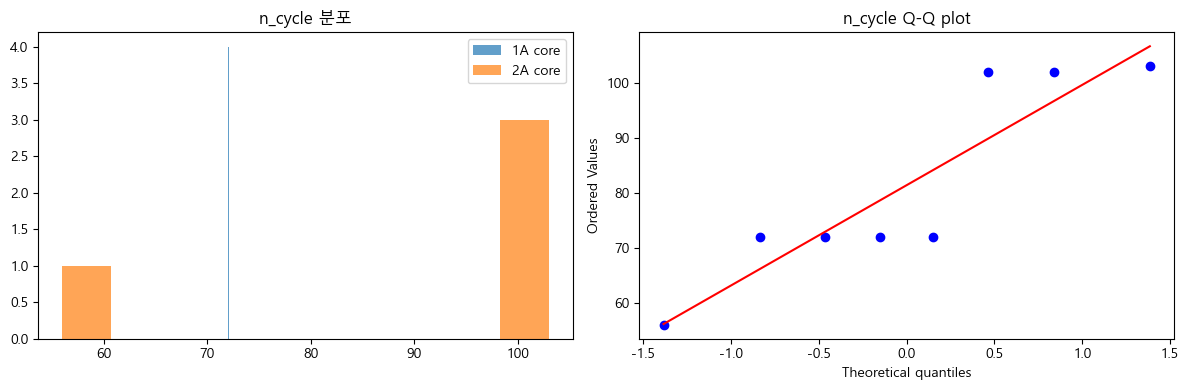

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(core_1a["n_cycle"], alpha=0.7, label="1A core")
axes[0].hist(core_2a["n_cycle"], alpha=0.7, label="2A core")
axes[0].set_title("n_cycle 분포")
axes[0].legend()

stats.probplot(core_summary["n_cycle"], dist="norm", plot=axes[1])
axes[1].set_title("n_cycle Q-Q plot")

plt.tight_layout()
plt.show()

n_cycle 분포
- 1A core는 72에 몰림
- 2A core는 56, 102, 102, 103처럼 퍼짐
- 1A는 균일
- 2A는 일부 배터리(B0053)가 짧고, 나머지는 길게 감

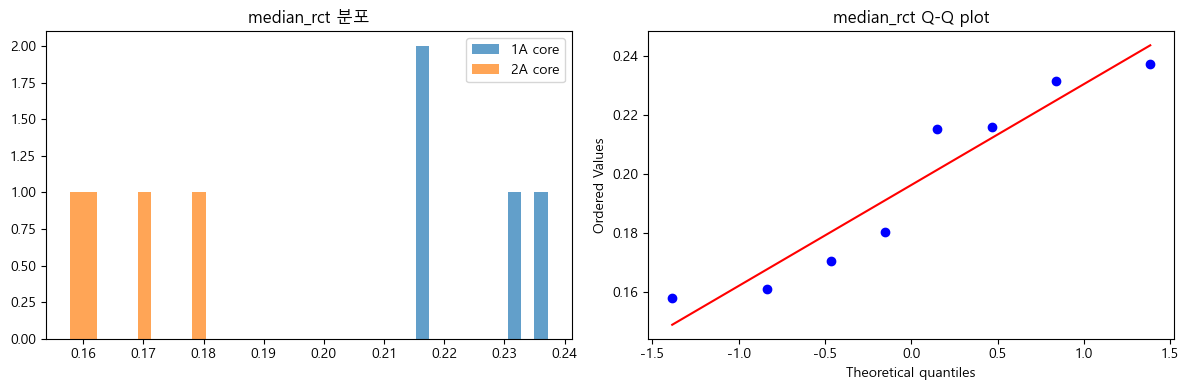

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(core_1a["median_rct"].dropna(), alpha=0.7, label="1A core")
axes[0].hist(core_2a["median_rct"].dropna(), alpha=0.7, label="2A core")
axes[0].set_title("median_rct 분포")
axes[0].legend()

stats.probplot(core_summary["median_rct"].dropna(), dist="norm", plot=axes[1])
axes[1].set_title("median_rct Q-Q plot")

plt.tight_layout()
plt.show()

median_rct 분포
- 1A는 대체로 0.215~0.237
- 2A는 0.16~0.18 부근
- 1A가 전반적으로 더 높은 Rct 영역에 있음
- Mann-Whitney 결과가 유의.

### Mann-Whitney U검정

이유:
- 표본 수가 매우 작다
- 정규성 판단을 강하게 믿기 어렵다
- 현재 질문은 대부분 두 그룹 비교

## 16. 가설 1: 1A와 2A core의 총 cycle 수는 차이가 있는가?

- 귀무가설 H0: 두 그룹의 총 cycle 분포는 같다
- 대립가설 H1: 두 그룹의 총 cycle 분포는 다르다

In [80]:
x = core_1a["n_cycle"].dropna().to_numpy()
y = core_2a["n_cycle"].dropna().to_numpy()

cycle_test = stats.mannwhitneyu(
    x,
    y,
    alternative="two-sided",
    method="exact"
)

cycle_test

MannwhitneyuResult(statistic=np.float64(4.0), pvalue=np.float64(0.34285714285714286))

In [81]:
diff_matrix = x[:, None] - y[None, :]

greater_count = (diff_matrix > 0).sum()
less_count = (diff_matrix < 0).sum()

cliffs_delta_cycle = (greater_count - less_count) / (len(x) * len(y))
cliffs_delta_cycle

np.float64(-0.5)

In [82]:
cycle_result = pd.DataFrame({
    "항목": ["n_cycle"],
    "1A_median": [core_1a["n_cycle"].median()],
    "2A_median": [core_2a["n_cycle"].median()],
    "U_statistic": [cycle_test.statistic],
    "p_value": [cycle_test.pvalue],
    "cliffs_delta": [cliffs_delta_cycle]
})

cycle_result

,항목,1A_median,2A_median,U_statistic,p_value,cliffs_delta
0,n_cycle,72.0,102.0,4.0,0.342857,-0.5


- 숫자만 보면 2A core가 cycle 수가 더 길어 보인다.
- 하지만 p > 0.05라서 통계적으로 유의하다고 말하기 어렵다.
- 표본이 각 4개뿐이라서 검정력이 약함.
- “2A가 더 길어 보이는 경향은 있지만, 이 표본만으로 확정하기 어렵다.”

## 17. 가설 2: 1A와 2A core의 종료 시점 SOH는 차이가 있는가?

In [83]:
x = core_1a["end_soh"].dropna().to_numpy()
y = core_2a["end_soh"].dropna().to_numpy()

end_soh_test = stats.mannwhitneyu(
    x,
    y,
    alternative="two-sided",
    method="exact"
)

end_soh_test

MannwhitneyuResult(statistic=np.float64(8.0), pvalue=np.float64(1.0))

In [84]:
diff_matrix = x[:, None] - y[None, :]

greater_count = (diff_matrix > 0).sum()
less_count = (diff_matrix < 0).sum()

cliffs_delta_end_soh = (greater_count - less_count) / (len(x) * len(y))
cliffs_delta_end_soh

np.float64(0.0)

In [85]:
end_soh_result = pd.DataFrame({
    "항목": ["end_soh"],
    "1A_median": [core_1a["end_soh"].median()],
    "2A_median": [core_2a["end_soh"].median()],
    "U_statistic": [end_soh_test.statistic],
    "p_value": [end_soh_test.pvalue],
    "cliffs_delta": [cliffs_delta_end_soh]
})

end_soh_result

,항목,1A_median,2A_median,U_statistic,p_value,cliffs_delta
0,end_soh,0.679239,0.375318,8.0,1.0,0.0


- 숫자상 중앙값 차이는 있어 보이는데
- 검정 결과는 전혀 유의하지 않음
- 특히 B0053, B0054의 end_soh=0 같은 값이 섞여 있어 해석이 더 불안정함
- 이 결과로는 1A와 2A의 종료 SOH 차이가 있다고 말하기 어렵다.

## 18. 가설 3: 1A와 2A core의 median Rct는 차이가 있는가?

In [86]:
x = core_1a["median_rct"].dropna().to_numpy()
y = core_2a["median_rct"].dropna().to_numpy()

rct_test = stats.mannwhitneyu(
    x,
    y,
    alternative="two-sided",
    method="exact"
)

rct_test

MannwhitneyuResult(statistic=np.float64(16.0), pvalue=np.float64(0.02857142857142857))

In [87]:
diff_matrix = x[:, None] - y[None, :]

greater_count = (diff_matrix > 0).sum()
less_count = (diff_matrix < 0).sum()

cliffs_delta_rct = (greater_count - less_count) / (len(x) * len(y))
cliffs_delta_rct

np.float64(1.0)

In [88]:
rct_result = pd.DataFrame({
    "항목": ["median_rct"],
    "1A_median": [core_1a["median_rct"].median()],
    "2A_median": [core_2a["median_rct"].median()],
    "U_statistic": [rct_test.statistic],
    "p_value": [rct_test.pvalue],
    "cliffs_delta": [cliffs_delta_rct]
})

rct_result

,항목,1A_median,2A_median,U_statistic,p_value,cliffs_delta
0,median_rct,0.223742,0.165616,16.0,0.028571,1.0


- p < 0.05라서 통계적으로 유의
- Cliff’s delta 1.0은 사실상 1A 그룹 값이 2A 그룹보다 전부 더 큰 수준의 매우 강한 방향성=.
- 1A core 그룹의 Rct가 2A core보다 유의하게 높다고 해석할 수 있습니다.

다만 주의점:

- 표본 수가 4 vs 4로 매우 작음
- Rct 매칭 방식이 완전히 엄밀하지 않을 수 있음
- 그래서 “강한 신호는 보이지만, 최종 결론은 조심”

## 19. 2A core와 2A crash를 따로 비교하기


정상 종료 cohort와 crash cohort가 얼마나 다른가

In [89]:
x = core_2a["n_cycle"].dropna().to_numpy()
y = crash_2a["n_cycle"].dropna().to_numpy()

core_vs_crash_cycle_test = stats.mannwhitneyu(
    x,
    y,
    alternative="two-sided",
    method="exact"
)

core_vs_crash_cycle_test

MannwhitneyuResult(statistic=np.float64(16.0), pvalue=np.float64(0.02857142857142857))

In [90]:
core_vs_crash_cycle = pd.DataFrame({
    "항목": ["n_cycle"],
    "2A_core_median": [core_2a["n_cycle"].median()],
    "2A_crash_median": [crash_2a["n_cycle"].median()],
    "U_statistic": [core_vs_crash_cycle_test.statistic],
    "p_value": [core_vs_crash_cycle_test.pvalue]
})

core_vs_crash_cycle

,항목,2A_core_median,2A_crash_median,U_statistic,p_value
0,n_cycle,102.0,23.0,16.0,0.028571


- crash군은 core군보다 훨씬 적은 cycle에서 끝난다.

- crash군은 수명 측면에서 분명히 불리하게 보인다.

## 20. 이상 배터리 비율 비교 (Fisher exact)

`anomaly_score >= 2`를 이상 배터리로 보고

- 1A core
- 2A core

사이의 비율 차이를 확인.

In [91]:
core_summary["bad_flag"] = (core_summary["anomaly_score"] >= 2).astype(int)

bad_ratio_table = pd.crosstab(core_summary["protocol_group"], core_summary["bad_flag"])
bad_ratio_table

bad_flag,0,1
protocol_group,,
G_4C_1A,4,0
G_4C_2A,3,1


In [92]:
fisher_table = [
    [
        bad_ratio_table.loc["G_4C_1A", 0],
        bad_ratio_table.loc["G_4C_1A", 1]
    ],
    [
        bad_ratio_table.loc["G_4C_2A", 0],
        bad_ratio_table.loc["G_4C_2A", 1]
    ]
]

fisher_result = stats.fisher_exact(fisher_table, alternative="two-sided")
fisher_result

SignificanceResult(statistic=inf, pvalue=1.0)

In [93]:
fisher_summary = pd.DataFrame({
    "항목": ["이상 배터리 비율"],
    "1A_bad_ratio": [core_1a["anomaly_score"].ge(2).mean()],
    "2A_bad_ratio": [core_2a["anomaly_score"].ge(2).mean()],
    "odds_ratio": [fisher_result.statistic],
    "p_value": [fisher_result.pvalue]
})

fisher_summary

,항목,1A_bad_ratio,2A_bad_ratio,odds_ratio,p_value
0,이상 배터리 비율,0.0,0.25,inf,1.0


- 비율만 보면 2A 쪽이 이상 배터리 비율이 더 높아 보입니다.
- 하지만 p > 0.05라서 유의하다고 말할 수는 없다.

## 21. cycle과 SOH의 관계 보기 (Spearman)

cycle이 진행될수록 SOH가 내려가는지 확인.  

In [94]:
core_cycle = cycle_table[cycle_table["analysis_role"] == "core"].copy()

spearman_cycle_soh = stats.spearmanr(
    core_cycle["cycle_index"],
    core_cycle["SOH"],
    nan_policy="omit"
)

spearman_cycle_soh

SignificanceResult(statistic=np.float64(-0.40828636640630483), pvalue=np.float64(1.5199872326838715e-27))

In [95]:
spearman_cycle_rct = stats.spearmanr(
    core_cycle["cycle_index"],
    core_cycle["Rct"],
    nan_policy="omit"
)

spearman_cycle_rct

SignificanceResult(statistic=np.float64(-0.08685601092165816), pvalue=np.float64(0.11530073274541927))

In [96]:
spearman_soh_rct = stats.spearmanr(
    core_cycle["SOH"],
    core_cycle["Rct"],
    nan_policy="omit"
)

spearman_soh_rct

SignificanceResult(statistic=np.float64(-0.5458600346980884), pvalue=np.float64(5.0882151422138066e-27))

In [ ]:
corr_summary = pd.DataFrame({
    "관계": [
        "cycle_index vs SOH",
        "cycle_index vs Rct",
        "SOH vs Rct"
    ],
    "spearman_rho": [
        spearman_cycle_soh.statistic,
        spearman_cycle_rct.statistic,
        spearman_soh_rct.statistic
    ],
    "p_value": [
        spearman_cycle_soh.pvalue,
        spearman_cycle_rct.pvalue,
        spearman_soh_rct.pvalue
    ]
})

corr_summary

,관계,spearman_rho,p_value
0,cycle_index vs SOH,-0.408286,1.519987e-27
1,cycle_index vs Rct,-0.086856,1.153007e-01
2,SOH vs Rct,-0.545860,5.088215e-27


cycle_index vs SOH
- cycle이 증가할수록 SOH가 감소하는 경향(음의 상관)
- 배터리를 많이 돌릴수록 성능이 떨어진다는 뜻

cycle_index vs Rct
- 거의 상관이 없음

SOH vs Rct
- SOH가 낮아질수록 Rct가 높아지는 경향(음의 상관)
- 배터리 성능이 나빠질수록 내부 저항 관련 지표(Rct)가 커지는 방향이다.

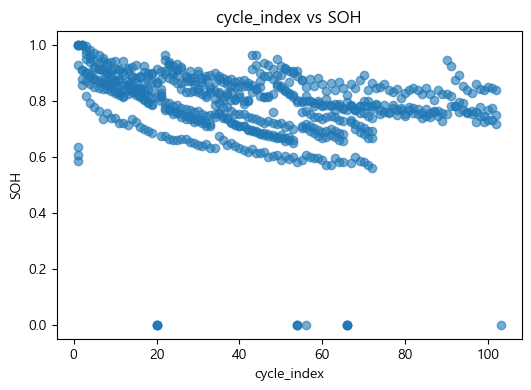

In [98]:
plt.figure(figsize=(6, 4))
plt.scatter(core_cycle["cycle_index"], core_cycle["SOH"], alpha=0.6)
plt.title("cycle_index vs SOH")
plt.xlabel("cycle_index")
plt.ylabel("SOH")
plt.show()

- 전체적으로 우하향
- cycle이 커질수록 SOH 내려감
- 중간에 0값 점들이 있음
- SOH=0 점들은 실제 물리현상보다 이상 기록 / 종료 레코드 / 0 capacity 문제 가능성을 의심해야함

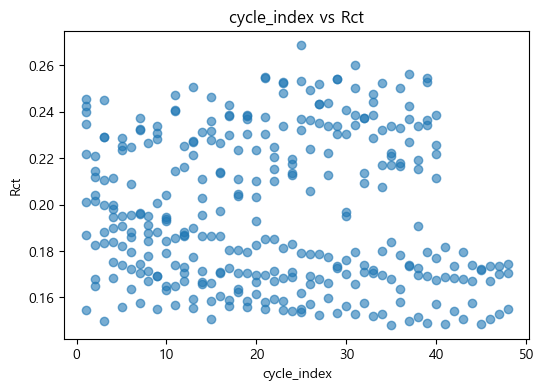

In [99]:
plt.figure(figsize=(6, 4))
plt.scatter(core_cycle["cycle_index"], core_cycle["Rct"], alpha=0.6)
plt.title("cycle_index vs Rct")
plt.xlabel("cycle_index")
plt.ylabel("Rct")
plt.show()

- 뚜렷한 우상향/우하향이 약함
- 여러 층으로 흩어져 있음
- Rct는 cycle 하나만으로 설명되지 않고 그룹 차이, 측정시점, 이상치 영향이 섞인 상태